In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import sys
sys.path.append('../scripts')
from utils import train_one_epoch, evaluate, EarlyStopping

# Configuration

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = '../data/' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')
MODEL_DIR = '../models/'
FIG_DIR = '../figures/'
RESULTS = '../results/'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


# Dataset Class (The NPZ Loader)

In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

# Prepare dataloaders

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ../data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


# EDA

Saved sample grid to: ../figures/eda_sample_grid.png


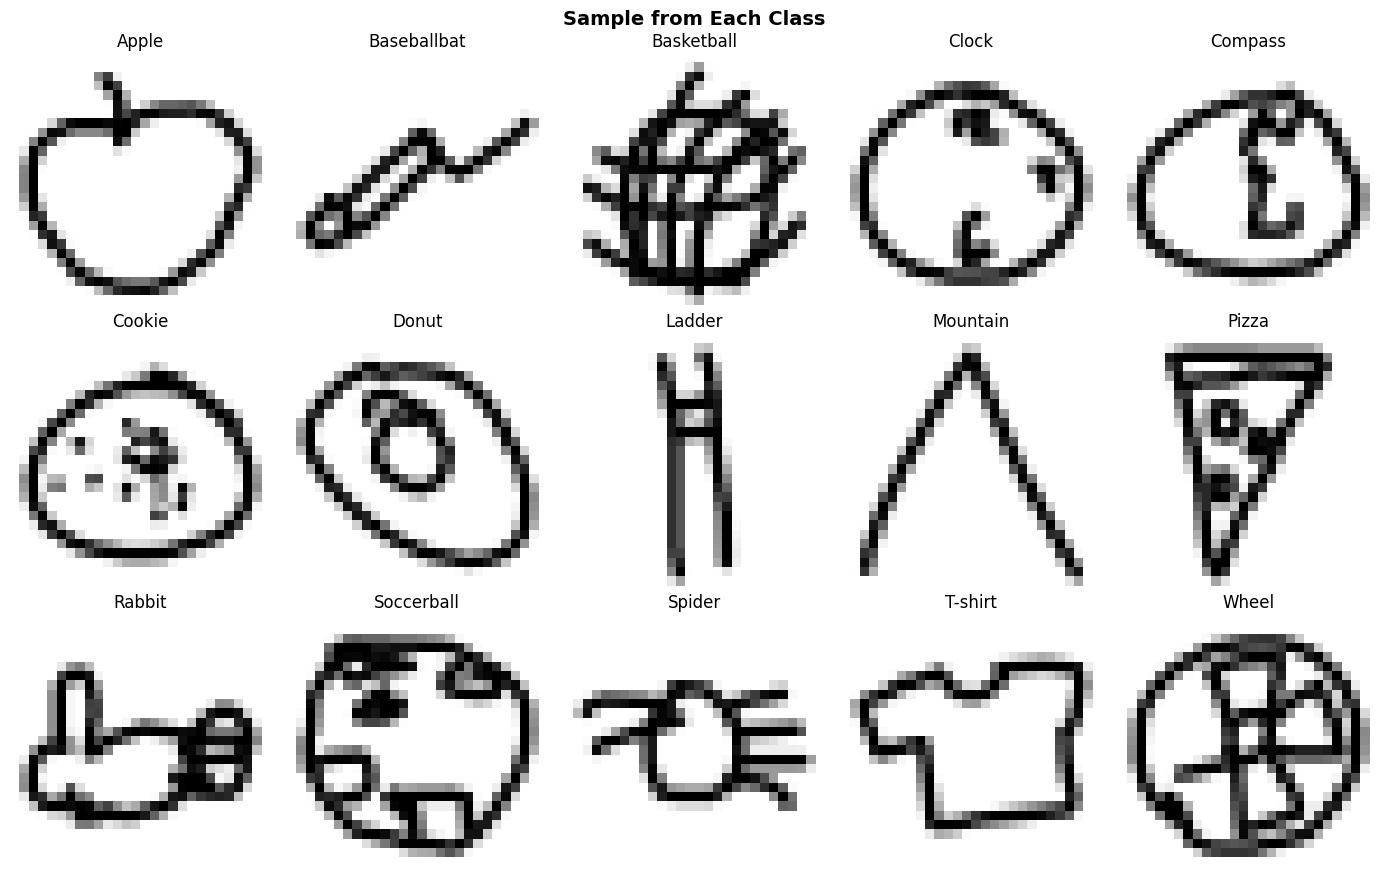

Saved class distribution to: ../figures/eda_class_distribution.png


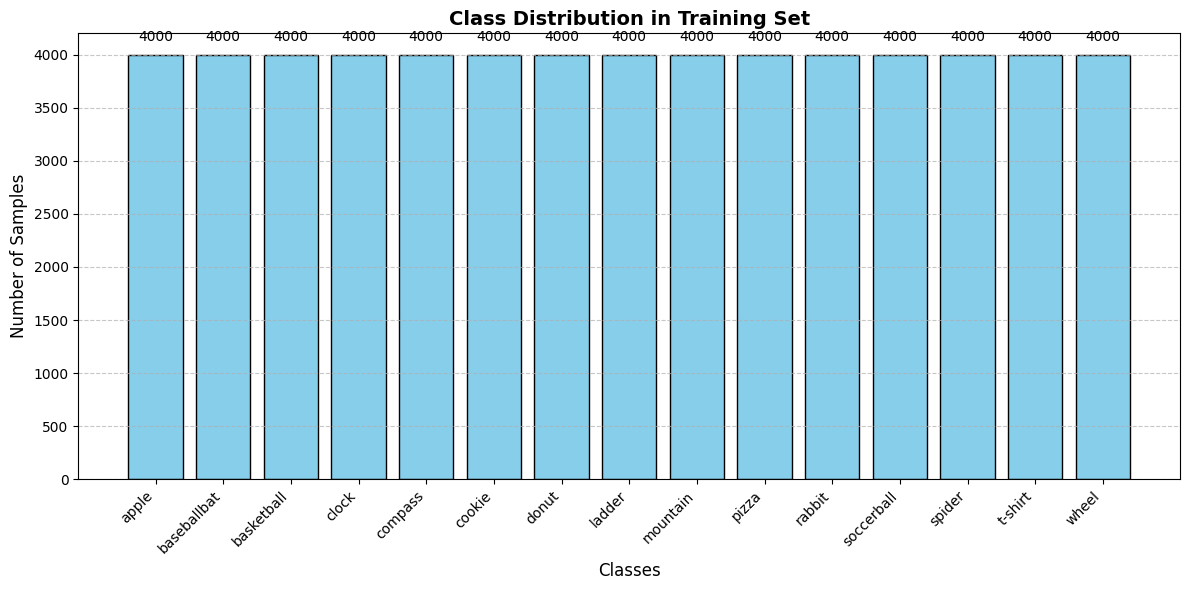

In [5]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================
# EDA

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
axes = axes.flatten()

for i in range(NUM_CLASSES):
    # Get all indices for this class from full dataset
    mask = full_train_dataset.y == i
    class_images = full_train_dataset.x[mask]
    # Extract the image, reshape it back to 28x28 for plotting
    sample = class_images[0].view(28, 28).numpy()

    # Plot the image
    axes[i].imshow(sample, cmap='gray_r') # reverse grayscale
    axes[i].set_title(CLASSES[i].capitalize(), fontsize=12)
    axes[i].axis('off')

fig.suptitle('Sample from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
grid_save_path = os.path.join(FIG_DIR, 'eda_sample_grid.png')
plt.savefig(grid_save_path, dpi=300, bbox_inches='tight')
print(f"Saved sample grid to: {grid_save_path}")
plt.show()

# Class distribution
# Extract all labels as a numpy array
labels_all = full_train_dataset.y.numpy()

# Count the occurrences of each class index
counts = np.bincount(labels_all)

# Plotting the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(CLASSES, counts, color='skyblue', edgecolor='black')

# Add the count numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, int(yval), 
             ha='center', va='bottom', fontsize=10)

plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
# Add a subtle grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
dist_save_path = os.path.join(FIG_DIR, 'eda_class_distribution.png')
plt.savefig(dist_save_path, dpi=300, bbox_inches='tight')
print(f"Saved class distribution to: {dist_save_path}")
plt.show()

# Part A: The Pancake Model (width focus)

In [21]:
# Helper functions

def count_parameters(model):
    """
    Counts the number of trainable parameters in a model.
    """
    total_params = 0
    for param in model.parameters():
        if param.requires_grad:
            total_params += param.numel()
    return total_params


def train_model(model, train_loader, val_loader, device, optimizer,
                num_epochs=40, scheduler=None, patience=5, min_delta=0.001, 
                metrics_save_path='results/metrics.json',
                weights_save_path=None):
    """
    Trains a PyTorch model and logs metrics, incorporating Early Stopping.
    Supports dynamic optimizers, learning-rate scheduling, and targeted weight saving.
    """
    print(f"Starting training for up to {num_epochs} epochs...")
    
    criterion = nn.CrossEntropyLoss()
    early_stopper = EarlyStopping(patience=patience, min_delta=min_delta, verbose=True)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scheduler=scheduler)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # Track Current LR
        current_lr = optimizer.param_groups[0]['lr']

        # Log Metrics
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f"Epoch {epoch+1}/{num_epochs} Complete | LR: {current_lr:.5f} |  Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f}")

        if scheduler is not None:
            # If it's the Plateau scheduler, step it here with val_loss
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            
            # If it's OneCycleLR, do NOTHING here (it's already stepped in the batch loop)
            elif isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
                pass 
            
            # For standard step schedulers (StepLR, CosineAnnealingLR)
            else:
                scheduler.step()

        early_stopper(val_loss, model)
        if early_stopper.early_stop:
            print("Early Stopping Triggered: Optimization Halting.")
            break
    
    # Always restore w_{t-p} to memory
    early_stopper.restore_best_weights(model)

    # Save metrics
    with open(metrics_save_path, 'w') as f:
        json.dump(history, f)
    print(f"Metrics saved to {metrics_save_path}")

    # Save weights
    if weights_save_path is not None:
        torch.save(model.state_dict(), weights_save_path)
        print(f"Weights saved to {weights_save_path}")

    return history

In [7]:
class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=2048, output_size=NUM_CLASSES):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        # Dropout to combat the massive memorization capacity
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = x.view(-1, 784) # (Batch, 28, 28) -> (Batch, 784)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

pancake_model = PancakeMLP().to(DEVICE)
print(f"Pancake MLP Parameters: {count_parameters(pancake_model)}")

Pancake MLP Parameters: 1638415


### Train Pancake MLP

In [8]:
# initialize AdamW optimizer: decouple weight decay from learning rate
optimizer_pancake = optim.AdamW(pancake_model.parameters(), lr=0.001, weight_decay=1e-4)

pancake_history = train_model(
    model=pancake_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=DEVICE,
    optimizer=optimizer_pancake,
    num_epochs=40,
    scheduler=None,
    patience=5,
    min_delta=0.0,
    metrics_save_path='../results/pancake_metrics.json',
    weights_save_path=None
)

Starting training for up to 40 epochs...


Validation Acc: 69.25%   Loss: 0.9653
Epoch 1/40 Complete | LR: 0.00100 |  Train Acc: 61.44% | Val Acc: 69.25% | Val Loss: 0.9653
Validation loss decreased (inf --> 0.9653). Saving optimal state...


Validation Acc: 70.81%   Loss: 0.9032
Epoch 2/40 Complete | LR: 0.00100 |  Train Acc: 71.45% | Val Acc: 70.81% | Val Loss: 0.9032
Validation loss decreased (0.9653 --> 0.9032). Saving optimal state...


Validation Acc: 73.12%   Loss: 0.8392
Epoch 3/40 Complete | LR: 0.00100 |  Train Acc: 75.13% | Val Acc: 73.12% | Val Loss: 0.8392
Validation loss decreased (0.9032 --> 0.8392). Saving optimal state...


Validation Acc: 73.99%   Loss: 0.8203
Epoch 4/40 Complete | LR: 0.00100 |  Train Acc: 78.10% | Val Acc: 73.99% | Val Loss: 0.8203
Validation loss decreased (0.8392 --> 0.8203). Saving optimal state...


...

Validation Acc: 76.06%   Loss: 0.7769
Epoch 7/40 Complete | LR: 0.00100 |  Train Acc: 84.18% | Val Acc: 76.06% | Val Loss: 0.7769
EarlyStopping counter: 1 out of 5


Validation Acc: 75.50%   Loss: 0.8024
Epoch 8/40 Complete | LR: 0.00100 |  Train Acc: 85.97% | Val Acc: 75.50% | Val Loss: 0.8024
EarlyStopping counter: 2 out of 5


Validation Acc: 76.64%   Loss: 0.7903
Epoch 9/40 Complete | LR: 0.00100 |  Train Acc: 87.50% | Val Acc: 76.64% | Val Loss: 0.7903
EarlyStopping counter: 3 out of 5


Validation Acc: 76.28%   Loss: 0.8108
Epoch 10/40 Complete | LR: 0.00100 |  Train Acc: 89.08% | Val Acc: 76.28% | Val Loss: 0.8108
EarlyStopping counter: 4 out of 5


Validation Acc: 76.38%   Loss: 0.8604
Epoch 11/40 Complete | LR: 0.00100 |  Train Acc: 90.20% | Val Acc: 76.38% | Val Loss: 0.8604
EarlyStopping counter: 5 out of 5
Early Stopping Triggered: Optimization Halting.
Restored best model weights from epoch t-p.
Metrics saved to ../results/pancake_metrics.json


# Part B: The Tower Model (depth focus)

In [9]:
class TowerMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, output_size=NUM_CLASSES):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        x = x.view(-1, 784)
        x = self.network(x)
        return x


tower_model = TowerMLP().to(DEVICE)
print(f"Tower MLP Parameters: {count_parameters(tower_model)}")

Tower MLP Parameters: 536847


### Train Tower MLP

In [10]:
optimizer_tower = optim.AdamW(tower_model.parameters(), lr=0.001, weight_decay=1e-4)

tower_history = train_model(
    model=tower_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=DEVICE,
    optimizer=optimizer_tower,
    num_epochs=40,
    scheduler=None,
    patience=8, # Increased patience for navigating deep network saddle points
    min_delta=0.001,
    metrics_save_path='../results/tower_metrics.json',
    weights_save_path=None
)

Starting training for up to 40 epochs...


Validation Acc: 71.56%   Loss: 0.8581
Epoch 1/40 Complete | LR: 0.00100 |  Train Acc: 65.89% | Val Acc: 71.56% | Val Loss: 0.8581
Validation loss decreased (inf --> 0.8581). Saving optimal state...


Validation Acc: 73.72%   Loss: 0.7834
Epoch 2/40 Complete | LR: 0.00100 |  Train Acc: 73.87% | Val Acc: 73.72% | Val Loss: 0.7834
Validation loss decreased (0.8581 --> 0.7834). Saving optimal state...


Validation Acc: 75.20%   Loss: 0.7560
Epoch 3/40 Complete | LR: 0.00100 |  Train Acc: 77.36% | Val Acc: 75.20% | Val Loss: 0.7560
Validation loss decreased (0.7834 --> 0.7560). Saving optimal state...


Validation Acc: 75.73%   Loss: 0.7476
Epoch 4/40 Complete | LR: 0.00100 |  Train Acc: 79.53% | Val Acc: 75.73% | Val Loss: 0.7476
Validation loss decreased (0.7560 --> 0.7476). Saving optimal state...


...

Validation Acc: 76.95%   Loss: 0.8032
Epoch 9/40 Complete | LR: 0.00100 |  Train Acc: 87.57% | Val Acc: 76.95% | Val Loss: 0.8032
EarlyStopping counter: 4 out of 8


Validation Acc: 76.81%   Loss: 0.8593
Epoch 10/40 Complete | LR: 0.00100 |  Train Acc: 88.73% | Val Acc: 76.81% | Val Loss: 0.8593
EarlyStopping counter: 5 out of 8


Validation Acc: 75.53%   Loss: 0.8980
Epoch 11/40 Complete | LR: 0.00100 |  Train Acc: 89.77% | Val Acc: 75.53% | Val Loss: 0.8980
EarlyStopping counter: 6 out of 8


Validation Acc: 76.15%   Loss: 0.9003
Epoch 12/40 Complete | LR: 0.00100 |  Train Acc: 90.84% | Val Acc: 76.15% | Val Loss: 0.9003
EarlyStopping counter: 7 out of 8


Validation Acc: 75.94%   Loss: 0.9428
Epoch 13/40 Complete | LR: 0.00100 |  Train Acc: 91.45% | Val Acc: 75.94% | Val Loss: 0.9428
EarlyStopping counter: 8 out of 8
Early Stopping Triggered: Optimization Halting.
Restored best model weights from epoch t-p.
Metrics saved to ../results/tower_metrics.json


# Part C: The Champion Model

In [43]:
import torchvision.transforms as T

# Load the raw training images
data = np.load(TRAIN_FILE)
x_train = data['x_train']
# Normalize to [0, 1]
x_train_float = x_train.astype(np.float32) / 255.0
# Calculate global mean and standard deviation
global_mean = np.mean(x_train_float)
global_std = np.std(x_train_float)

class AugmentedQuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train', transform=None):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train', 'val', or 'test'
            transform (callable, optional): Torchvision transform pipeline
        """
        self.mode = mode
        self.transform = transform

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        data = np.load(file_path)

        if mode in ['train', 'val']:
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
        elif mode == 'test':
            self.x = data['test_images']
            self.y = None

        # Convert to Float
        self.x = torch.from_numpy(self.x).float()
        
        # Convert to [0, 1] then Standardize using the global stats
        self.x = (self.x / 255.0 - global_mean) / global_std

        # Reshape to (Batch, Channels, Height, Width) for torchvision transforms
        self.x = self.x.view(-1, 1, 28, 28) # [N, 1, 28, 28]

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        
        # Apply random augmentations during training
        if self.transform is not None:
            img = self.transform(img)
            
            # # Add Gaussian Noise (Mean=0, Std=0.05) to regularize stroke variations
            # noise = torch.randn_like(img) * 0.05
            # img = img + noise

        # Flatten back to 784 for the MLP
        img = img.view(-1)

        if self.mode in ['train', 'val']:
            return img, self.y[idx]
        else:
            return img

# Define the Spatial Augmentation Pipeline
train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=10, translate=(0.08, 0.08))
])

# Initialize datasets
train_dataset_full = AugmentedQuickDrawDataset(TRAIN_FILE, mode='train', transform=train_transforms)
val_dataset_full   = AugmentedQuickDrawDataset(TRAIN_FILE, mode='val', transform=None)
NUM_CLASSES = len(train_dataset_full.classes)

# Generate random, non-overlapping indices for an 80/20 split
total_size = len(train_dataset_full)
indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(SEED)).tolist()
train_size = int(0.8 * total_size)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create subsets using the specific dataset objects
train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices)
val_dataset = torch.utils.data.Subset(val_dataset_full, val_indices)

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"Augmented Train samples: {len(train_dataset)} | Original Validation samples: {len(val_dataset)}")

Augmented Train samples: 48000 | Original Validation samples: 12000


In [44]:
import math

class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, output_size=NUM_CLASSES):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 400),
            nn.SELU(),
            nn.AlphaDropout(0.1),
            
            nn.Linear(400, 256),
            nn.SELU(),
            nn.AlphaDropout(0.05),
            
            nn.Linear(256, 128),
            nn.SELU(),
            
            nn.Linear(128, output_size)
        )
        
        # Apply strict LeCun Normal Initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # LeCun Normal: mean=0, std = 1 / sqrt(fan_in)
            # fan_in = number of input features
            fan_in = m.weight.size(1)
            nn.init.normal_(m.weight, mean=0.0, std=math.sqrt(1.0 / fan_in))
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)

champion_model = ChampionMLP().to(DEVICE)
print(f"Champion MLP Parameters: {count_parameters(champion_model)}")

Champion MLP Parameters: 451487


### Train Champion Model

In [46]:
optimizer_champ = optim.AdamW(champion_model.parameters(), lr=0.001, weight_decay=1e-4)
epochs_planned = 20
total_steps = epochs_planned * len(train_loader)

scheduler_champ = optim.lr_scheduler.OneCycleLR(
    optimizer_champ,
    max_lr=0.005,
    total_steps=total_steps,
    pct_start=0.3,        # Warm up for ~5 epochs
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1e4
)

champion_history = train_model(
    model=champion_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=DEVICE,
    optimizer=optimizer_champ,
    num_epochs=epochs_planned,
    scheduler=scheduler_champ,
    patience=20, 
    min_delta=0.0,
    metrics_save_path='../results/champion_metrics.json',
    weights_save_path='../models/champion_weights.pth' 
)

Starting training for up to 20 epochs...


Validation Acc: 77.38%   Loss: 0.6894
Epoch 1/20 Complete | LR: 0.00080 |  Train Acc: 74.12% | Val Acc: 77.38% | Val Loss: 0.6894
Validation loss decreased (inf --> 0.6894). Saving optimal state...


Validation Acc: 75.55%   Loss: 0.7599
Epoch 2/20 Complete | LR: 0.00163 |  Train Acc: 72.92% | Val Acc: 75.55% | Val Loss: 0.7599
EarlyStopping counter: 1 out of 20


Validation Acc: 72.61%   Loss: 0.8587
Epoch 3/20 Complete | LR: 0.00275 |  Train Acc: 70.80% | Val Acc: 72.61% | Val Loss: 0.8587
EarlyStopping counter: 2 out of 20


Validation Acc: 72.53%   Loss: 0.8571
Epoch 4/20 Complete | LR: 0.00388 |  Train Acc: 69.19% | Val Acc: 72.53% | Val Loss: 0.8571
EarlyStopping counter: 3 out of 20


...

Validation Acc: 80.28%   Loss: 0.6329
Epoch 16/20 Complete | LR: 0.00094 |  Train Acc: 77.27% | Val Acc: 80.28% | Val Loss: 0.6329
Validation loss decreased (0.6528 --> 0.6329). Saving optimal state...


Validation Acc: 80.62%   Loss: 0.6165
Epoch 17/20 Complete | LR: 0.00054 |  Train Acc: 78.02% | Val Acc: 80.62% | Val Loss: 0.6165
Validation loss decreased (0.6329 --> 0.6165). Saving optimal state...


Validation Acc: 81.03%   Loss: 0.6015
Epoch 18/20 Complete | LR: 0.00025 |  Train Acc: 78.43% | Val Acc: 81.03% | Val Loss: 0.6015
Validation loss decreased (0.6165 --> 0.6015). Saving optimal state...


Validation Acc: 81.28%   Loss: 0.5969
Epoch 19/20 Complete | LR: 0.00006 |  Train Acc: 78.95% | Val Acc: 81.28% | Val Loss: 0.5969
Validation loss decreased (0.6015 --> 0.5969). Saving optimal state...


Validation Acc: 81.22%   Loss: 0.5969
Epoch 20/20 Complete | LR: 0.00000 |  Train Acc: 79.11% | Val Acc: 81.22% | Val Loss: 0.5969
Validation loss decreased (0.5969 --> 0.5969). Saving optimal state...
Restored best model weights from epoch t-p.
Metrics saved to ../results/champion_metrics.json
Weights saved to ../models/champion_weights.pth


# Analysis

### Model Comparison Summary Table

In [ ]:
import pandas as pd
from IPython.display import display

def load_metrics(filepath):
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            return json.load(f)
    print(f"Warning: Could not find {filepath}")
    return None

# Load histories from JSON
tower_hist = load_metrics('../results/tower_metrics.json')
pancake_hist = load_metrics('../results/pancake_metrics.json')
champion_hist = load_metrics('../results/champion_metrics.json')

table_data = []
models_info = [
    ("Tower MLP", tower_hist, tower_model),
    ("Pancake MLP", pancake_hist, pancake_model),
    ("Champion MLP", champion_hist, champion_model)
]

for name, hist, model in models_info:
    if hist is not None:
        epochs_run = len(hist['val_acc'])
        # Find the epoch with the highest validation accuracy
        best_epoch_idx = np.argmax(hist['val_acc'])
        best_val_acc = hist['val_acc'][best_epoch_idx]
        corresponding_train_acc = hist['train_acc'][best_epoch_idx]
        
        # Count trainable parameters
        params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        table_data.append([
            name, 
            f"{params:,}", 
            epochs_run, 
            f"{corresponding_train_acc:.2f}%", 
            f"{best_val_acc:.2f}%"
        ])

# Create and display the DataFrame
df_summary = pd.DataFrame(table_data, columns=[
    "Model", "Parameters", "Epochs Run", "Train Acc (at Best Val)", "Best Val Acc"
])

# Display table
display(df_summary.style.set_caption("Model Performance Summary").set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold')]
}]))

,Model,Parameters,Epochs Run,Train Acc (at Best Val),Best Val Acc
0,Tower MLP,"536,847",13,87.57%,76.95%
1,Pancake MLP,"1,638,415",11,87.50%,76.64%
2,Champion MLP,"451,487",20,78.95%,81.28%


### Confusion Matrix

Generating predictions for Confusion Matrix...
Saved confusion matrix to: ../figures/confusion_matrix.png


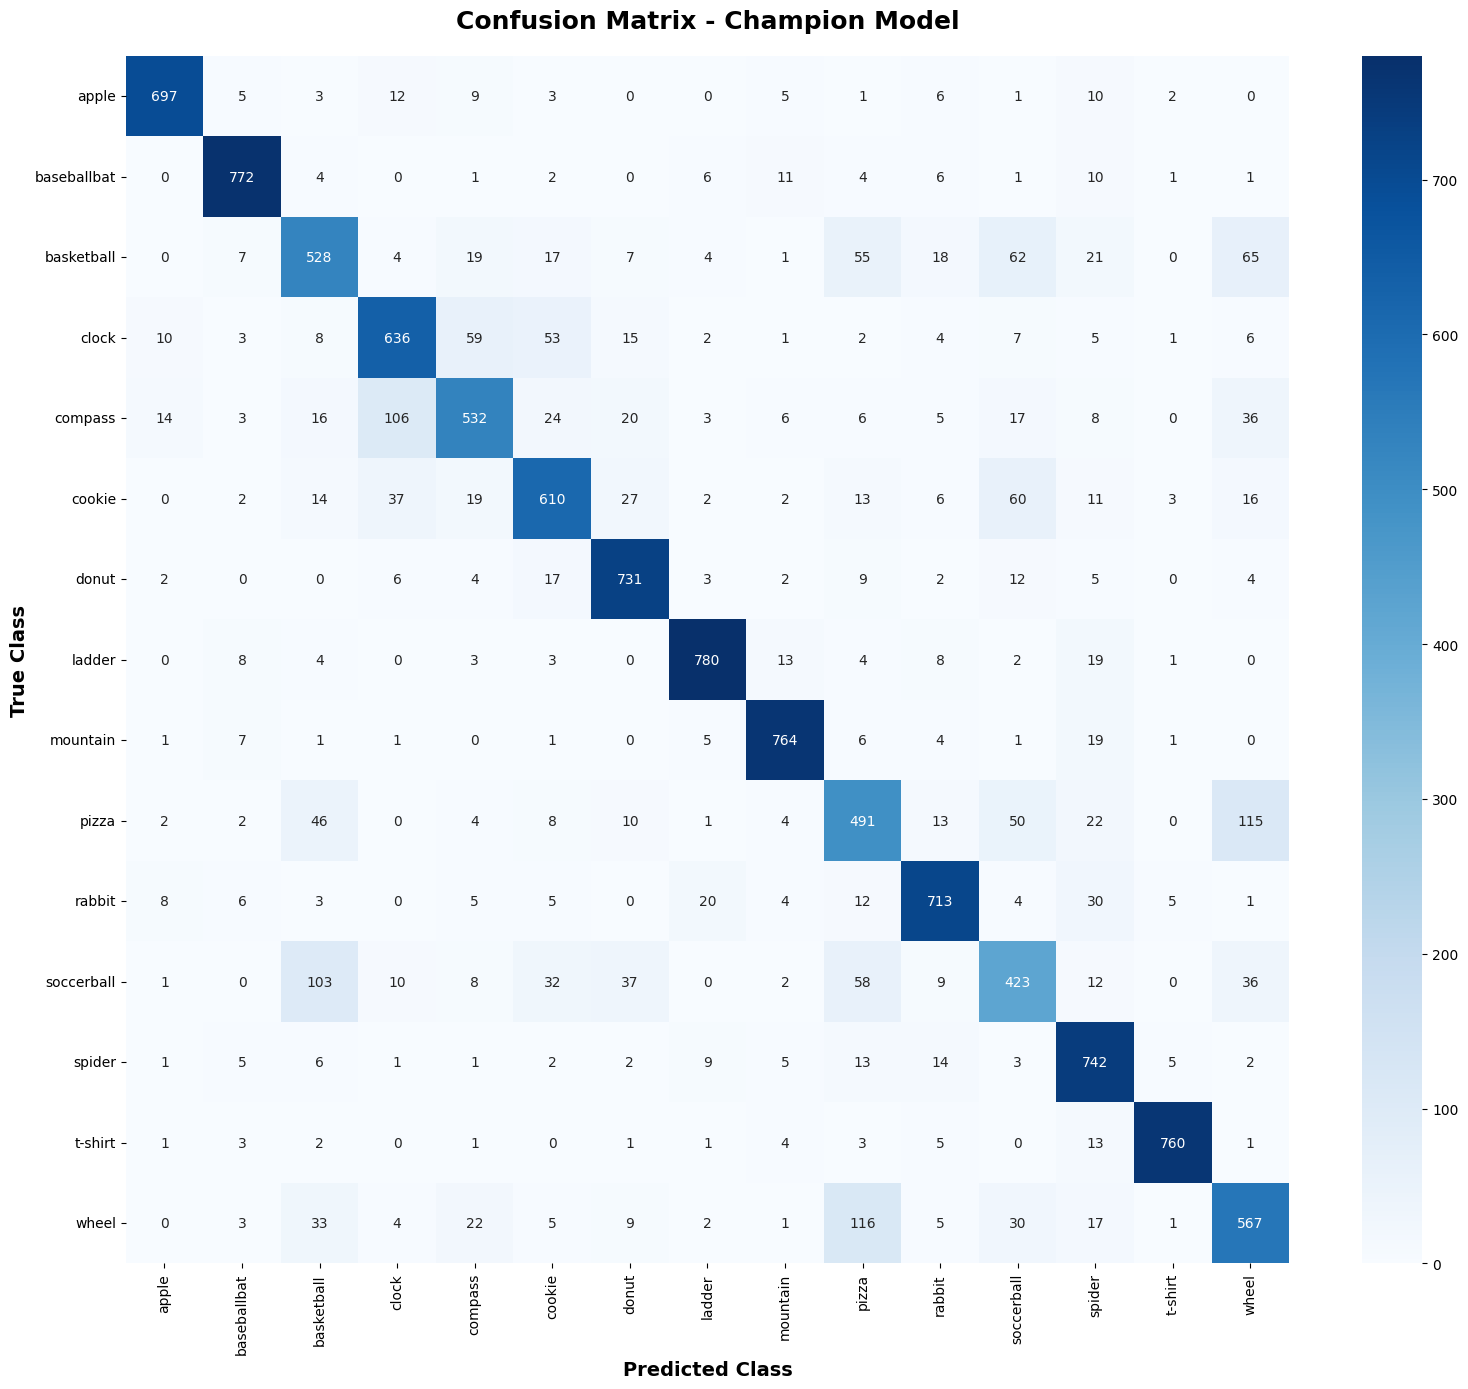

In [51]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    print("Generating predictions for Confusion Matrix...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute the matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.xlabel('Predicted Class', fontsize=14, fontweight='bold')
    plt.ylabel('True Class', fontsize=14, fontweight='bold')
    plt.title('Confusion Matrix - Champion Model', fontsize=18, fontweight='bold', pad=20)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    confusion_save_path = os.path.join(FIG_DIR, 'confusion_matrix.png')
    plt.savefig(confusion_save_path, dpi=300, bbox_inches='tight')
    print(f"Saved confusion matrix to: {confusion_save_path}")
    plt.show()

# Ensure you pass the correct class names list here (using train_dataset_full.classes)
plot_confusion_matrix(champion_model, val_loader, DEVICE, train_dataset_full.classes)

### Accuracy & Loss Curves

Saved Loss/Acc curves to: ../figures/acc_loss_curves.png


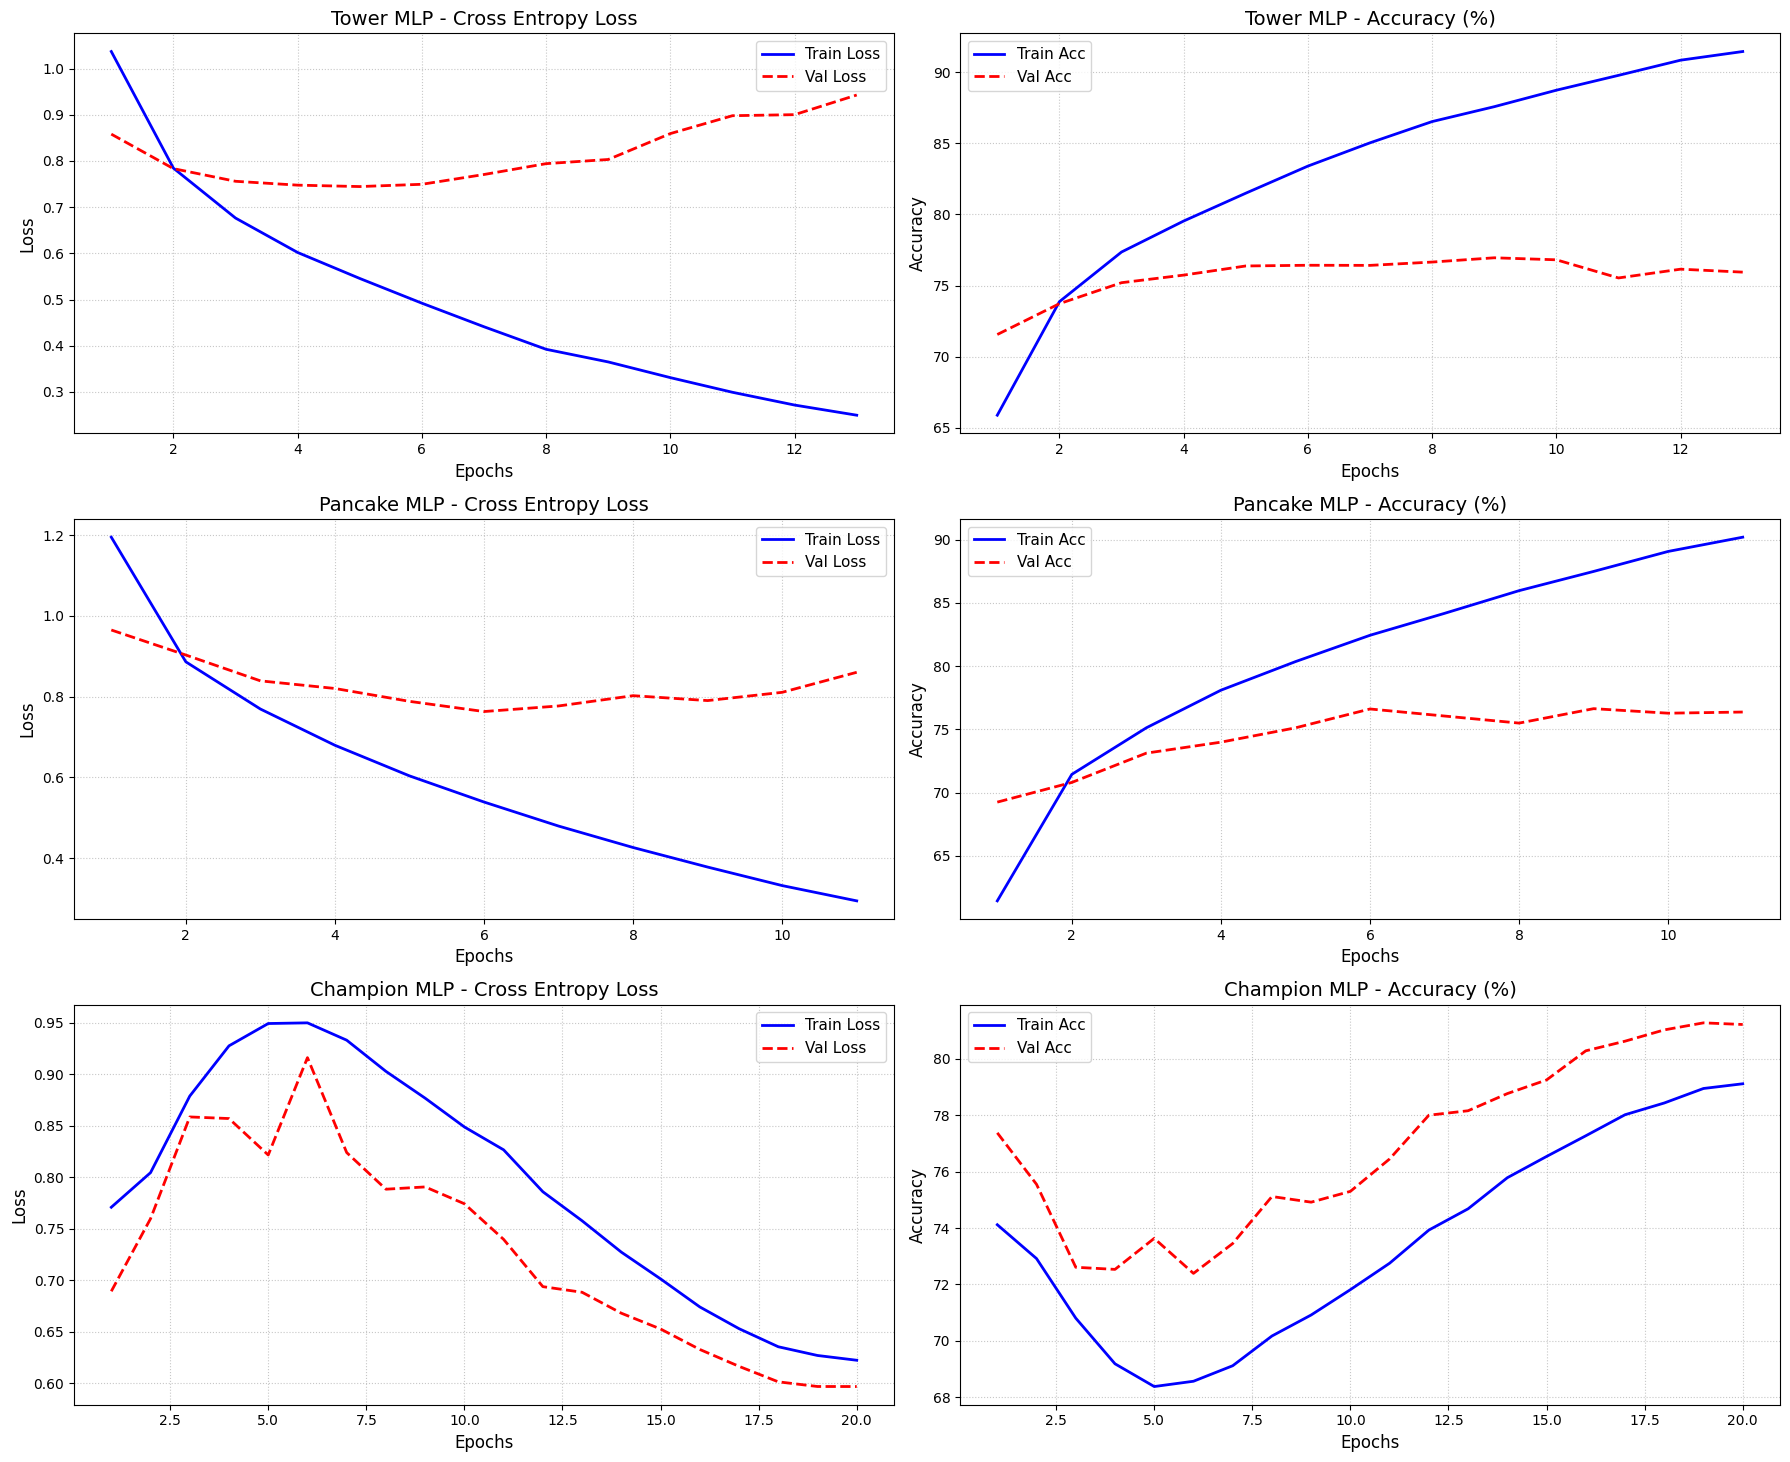

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
# fig.suptitle('Training and Validation Metrics Across All Experiments', fontsize=22, fontweight='bold', y=0.98)

experiments = [
    ("Tower MLP", tower_hist),
    ("Pancake MLP", pancake_hist),
    ("Champion MLP", champion_hist)
]

for i, (name, hist) in enumerate(experiments):
    if hist is None:
        continue
        
    epochs = range(1, len(hist['train_acc']) + 1)
    
    # --- Plot Loss (Left Column) ---
    axes[i, 0].plot(epochs, hist['train_loss'], label='Train Loss', color='blue', linewidth=2)
    axes[i, 0].plot(epochs, hist['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{name} - Cross Entropy Loss', fontsize=14)
    axes[i, 0].set_xlabel('Epochs', fontsize=12)
    axes[i, 0].set_ylabel('Loss', fontsize=12)
    axes[i, 0].legend(fontsize=11)
    axes[i, 0].grid(True, linestyle=':', alpha=0.7)
    
    # --- Plot Accuracy (Right Column) ---
    axes[i, 1].plot(epochs, hist['train_acc'], label='Train Acc', color='blue', linewidth=2)
    axes[i, 1].plot(epochs, hist['val_acc'], label='Val Acc', color='red', linestyle='--', linewidth=2)
    axes[i, 1].set_title(f'{name} - Accuracy (%)', fontsize=14)
    axes[i, 1].set_xlabel('Epochs', fontsize=12)
    axes[i, 1].set_ylabel('Accuracy', fontsize=12)
    axes[i, 1].legend(fontsize=11)
    axes[i, 1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit the main title
curves_save_path = os.path.join(FIG_DIR, 'acc_loss_curves.png')
plt.savefig(curves_save_path, dpi=300, bbox_inches='tight')
print(f"Saved Loss/Acc curves to: {curves_save_path}")
plt.show()

# Inference and Leaderboard Verification

In [54]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = AugmentedQuickDrawDataset(TEST_FILE, mode='test', transform=None)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(champion_model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [52]:
def print_model_size(champion_model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 451,487
  ✅ Parameter count is within limits.
